# Exploration des données - prédiction de la consommation énergétique

Objectif de ce notebook : analyser les données de consommation énergétique des foyers afin de comprendre les principaux facteurs qui influencent la consommation, comme la taille du foyer, la température moyenne, la présence de climatisation et l’usage pendant les heures de pointe.

Cette EDA permet aussi de préparer les variables utiles pour construire ensuite un modèle de machine learning supervisé de régression. La variable cible du modèle sera `Energy_Consumption_kWh`, c’est-à-dire la consommation énergétique du foyer en kWh.

Point de vigilance : le dataset couvre une période courte, du 1er avril 2025 au 8 avril 2025. L’analyse permet donc d’étudier les relations entre les variables sur cette période, mais ne permet pas de conclure sur des tendances longues ou saisonnières.

## Plan de l'EDA

1. Chargement et verification des datasets
2. Controle qualite : types, valeurs manquantes, doublons...
3. Analyse descriptive des variables principales
4. Analyse des profils clients

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "data" / "household_energy_consumption.csv").exists()
    ),
    Path.cwd(),
)
DATA_PATH = PROJECT_ROOT / "data" / "household_energy_consumption.csv"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PLOT_PALETTE = ["#2A9D8F", "#E76F51", "#457B9D", "#F4A261", "#8D6A9F", "#90BE6D"]
sns.set_theme(style="whitegrid", context="notebook", palette=PLOT_PALETTE, font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FBFCFE",
    "axes.edgecolor": "#D7DEE8",
    "axes.labelcolor": "#273142",
    "axes.titlecolor": "#111827",
    "axes.titleweight": "bold",
    "grid.color": "#E7EBF0",
    "grid.linewidth": 0.8,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.facecolor": "white",
    "legend.edgecolor": "#E1E6EF",
})


def finalize_plot(fig, filename):
    """Apply shared styling and export the figure to the plots folder."""
    sns.despine(fig=fig, trim=True)
    fig.tight_layout()
    output_path = PLOTS_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    return output_path

## 1. Chargement des donnees

In [2]:
# Chargement des donnees

df = pd.read_csv(DATA_PATH)

datasets_overview = pd.DataFrame({
    "dataset": ["consommation"],
    "lignes": [len(df)],
    "colonnes": [df.shape[1]],
})

datasets_overview

,dataset,lignes,colonnes
0,consommation,90000,7


## 2. Controle qualite

On verifie les types, les valeurs manquantes, les doublons et les incoherences simples avant de produire des graphiques. Cette etape evite d'interpreter des distributions faussees.

In [3]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Has_AC"] = df["Has_AC"].astype("string").str.strip().str.title()
df["Has_AC_Binary"] = df["Has_AC"].map({"Yes": 1, "No": 0})

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day_of_week"] = df["Date"].dt.day_name()
df["week"] = df["Date"].dt.isocalendar().week.astype("Int64")

df["consumption_per_person"] = df["Energy_Consumption_kWh"] / df["Household_Size"].replace(0, np.nan)
df["peak_usage_ratio"] = df["Peak_Hours_Usage_kWh"] / df["Energy_Consumption_kWh"].replace(0, np.nan)

df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,Has_AC_Binary,year,month,day_of_week,week,consumption_per_person,peak_usage_ratio
0,H00001,2025-04-01,8.4,4,17.8,No,3.2,0,2025,4,Tuesday,14,2.100,0.380952
1,H00001,2025-04-02,7.9,4,17.3,No,2.8,0,2025,4,Wednesday,14,1.975,0.354430
2,H00001,2025-04-03,9.2,4,18.6,No,3.0,0,2025,4,Thursday,14,2.300,0.326087
3,H00001,2025-04-04,7.9,4,18.2,No,2.7,0,2025,4,Friday,14,1.975,0.341772
4,H00001,2025-04-05,9.6,4,11.9,No,3.2,0,2025,4,Saturday,14,2.400,0.333333


In [4]:
# Vérification de la qualité des données

quality_report = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "valeurs_manquantes": df.isna().sum(),
    "taux_valeurs_manquantes": df.isna().mean(),
    "valeurs_uniques": df.nunique()
})

quality_report

,type,valeurs_manquantes,taux_valeurs_manquantes,valeurs_uniques
Household_ID,object,0,0.0,12857
Date,datetime64[ns],0,0.0,8
Energy_Consumption_kWh,float64,0,0.0,196
Household_Size,int64,0,0.0,6
Avg_Temperature_C,float64,0,0.0,151
Has_AC,string,0,0.0,2
Peak_Hours_Usage_kWh,float64,0,0.0,99
Has_AC_Binary,int64,0,0.0,2
year,int32,0,0.0,1
month,int32,0,0.0,1


In [5]:
# Vérification des doublons et informations générales

duplicate_rows = df.duplicated().sum()
duplicate_household_date = df.duplicated(subset=["Household_ID", "Date"]).sum()

print("Doublons exacts :", duplicate_rows)
print("Doublons Household_ID + Date :", duplicate_household_date)
print("Nombre de foyers distincts :", df["Household_ID"].nunique())
print("Période couverte :", df["Date"].min(), "->", df["Date"].max())

Doublons exacts : 0
Doublons Household_ID + Date : 0
Nombre de foyers distincts : 12857
Période couverte : 2025-04-01 00:00:00 -> 2025-04-08 00:00:00


In [6]:
# Vérification de la cohérence des données

coherence_checks = pd.Series({
    "consommation_negative_or_zero": (df["Energy_Consumption_kWh"] <= 0).sum(),
    "peak_usage_negative": (df["Peak_Hours_Usage_kWh"] < 0).sum(),
    "peak_usage_greater_than_total": (df["Peak_Hours_Usage_kWh"] > df["Energy_Consumption_kWh"]).sum(),
    "household_size_invalid": (df["Household_Size"] <= 0).sum(),
    "date_missing_or_invalid": df["Date"].isna().sum(),
})

coherence_checks.to_frame(name="nombre")

,nombre
consommation_negative_or_zero,0
peak_usage_negative,0
peak_usage_greater_than_total,0
household_size_invalid,0
date_missing_or_invalid,0


## 3. Analyse descriptive

Les variables clés pour prédire la consommation énergétique sont la consommation en heures de pointe, la taille du foyer, la température moyenne, la présence de climatisation et les indicateurs créés comme la consommation par personne et la part de consommation en heures de pointe.

In [7]:
numeric_columns = [
    "Energy_Consumption_kWh",
    "Peak_Hours_Usage_kWh",
    "peak_usage_ratio",
    "Household_Size",
    "consumption_per_person",
    "Avg_Temperature_C",
]

df[numeric_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Energy_Consumption_kWh,90000.0,10.571988,5.519494,0.50,0.6,2.300000,6.00,10.4,14.80,20.000000,20.0,20.000000
Peak_Hours_Usage_kWh,90000.0,4.319557,2.531432,0.20,0.2,0.800000,2.30,4.0,6.00,9.000000,9.8,10.000000
peak_usage_ratio,90000.0,0.399907,0.057862,0.25,0.3,0.309735,0.35,0.4,0.45,0.490000,0.5,0.555556
Household_Size,90000.0,3.487811,1.709761,1.00,1.0,1.000000,2.00,3.0,5.00,6.000000,6.0,6.000000
consumption_per_person,90000.0,3.081502,0.955626,0.25,0.6,1.700000,2.45,3.1,3.62,4.633333,6.0,10.500000
Avg_Temperature_C,90000.0,17.505802,2.491621,10.00,11.7,13.400000,15.80,17.5,19.20,21.700000,23.3,25.000000


In [8]:
df["Peak_Hours_Usage_kWh"].head(20)

0     3.2
1     2.8
2     3.0
3     2.7
4     3.2
5     2.8
6     3.2
7     4.2
8     4.9
9     4.5
10    4.1
11    5.1
12    4.8
13    3.9
14    2.7
15    2.5
16    2.2
17    3.1
18    2.9
19    2.4
Name: Peak_Hours_Usage_kWh, dtype: float64

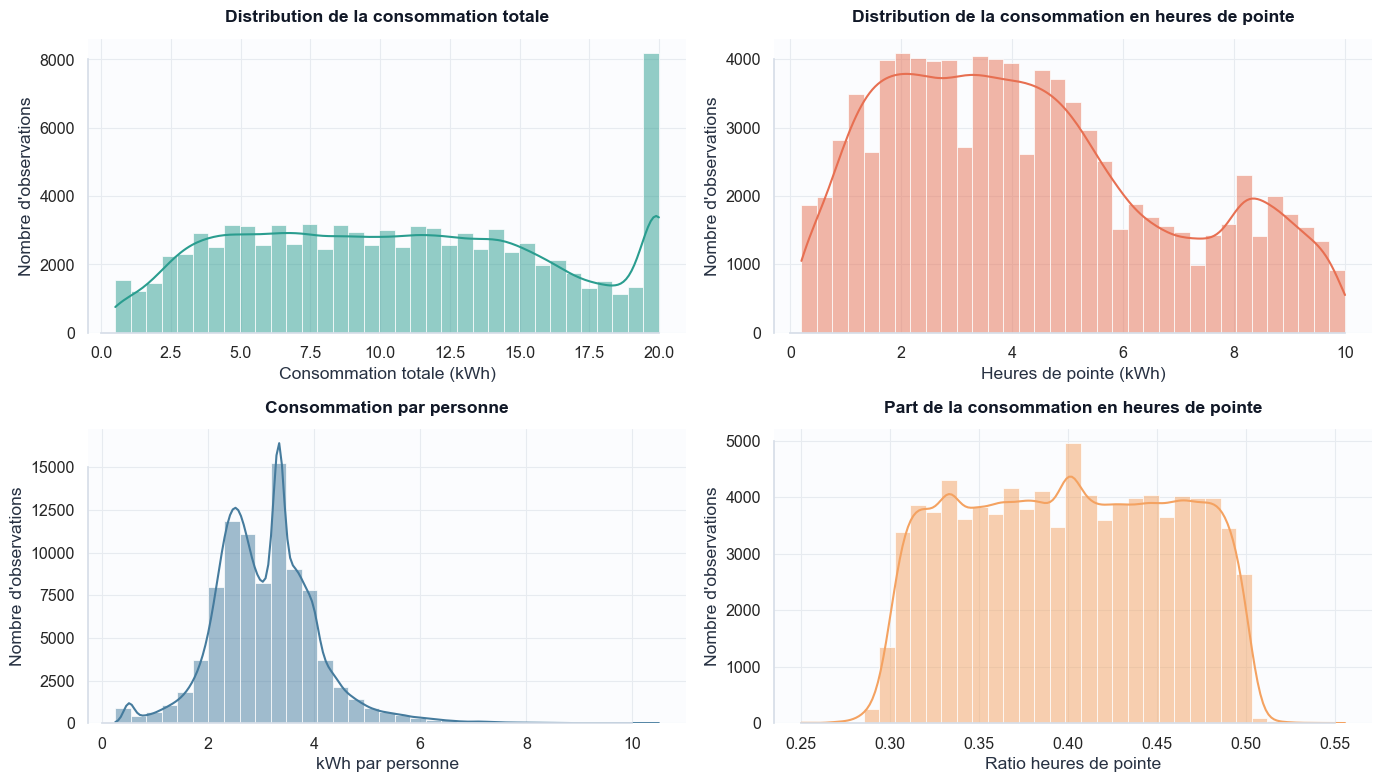

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)

hist_specs = [
    ("Energy_Consumption_kWh", "Distribution de la consommation totale", "Consommation totale (kWh)", PLOT_PALETTE[0]),
    ("Peak_Hours_Usage_kWh", "Distribution de la consommation en heures de pointe", "Heures de pointe (kWh)", PLOT_PALETTE[1]),
    ("consumption_per_person", "Consommation par personne", "kWh par personne", PLOT_PALETTE[2]),
    ("peak_usage_ratio", "Part de la consommation en heures de pointe", "Ratio heures de pointe", PLOT_PALETTE[3]),
]

for ax, (column, title, xlabel, color) in zip(axes.flat, hist_specs):
    values = df[column].clip(0, 1.5) if column == "peak_usage_ratio" else df[column]
    sns.histplot(values, bins=35, kde=True, color=color, edgecolor="white", linewidth=0.5, ax=ax)
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Nombre d'observations")

finalize_plot(fig, "distributions_consommation.png")
plt.show()

Interprétation des distributions

Le premier graphique montre la distribution de la consommation énergétique totale. Les valeurs sont réparties entre environ 0 et 20 kWh, avec une forte concentration proche de 20 kWh. Cela indique que plusieurs foyers atteignent des niveaux élevés de consommation.

Le deuxième graphique montre la distribution de la consommation en heures de pointe. La plupart des valeurs se situent entre 1 et 6 kWh, avec quelques consommations plus élevées autour de 8 à 10 kWh. Cela montre que les heures de pointe représentent une part importante de la consommation.

Le troisième graphique montre la consommation par personne. La majorité des foyers se situe autour de 2 à 4 kWh par personne. Cela permet de comparer les foyers de tailles différentes de manière plus juste.

Le quatrième graphique montre la part de la consommation réalisée en heures de pointe. La plupart des valeurs sont comprises entre 0,30 et 0,50, ce qui signifie que les heures de pointe représentent souvent entre 30 % et 50 % de la consommation totale.

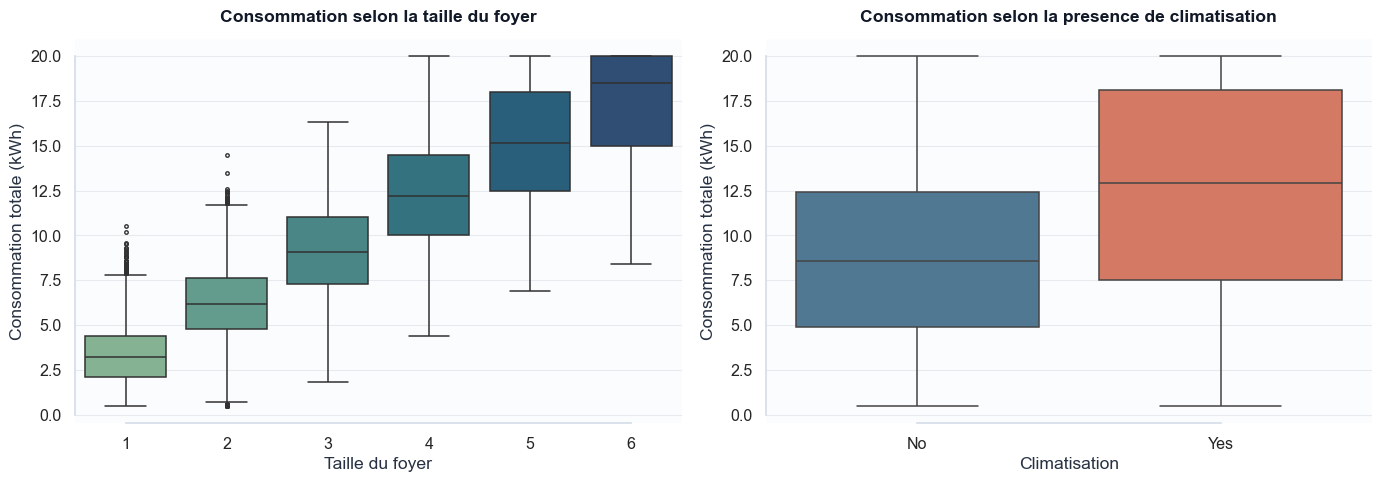

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="Household_Size",
    y="Energy_Consumption_kWh",
    palette="crest",
    linewidth=1.1,
    fliersize=2.5,
    ax=axes[0],
)
axes[0].set_title("Consommation selon la taille du foyer", pad=12)
axes[0].set_xlabel("Taille du foyer")
axes[0].set_ylabel("Consommation totale (kWh)")

sns.boxplot(
    data=df,
    x="Has_AC",
    y="Energy_Consumption_kWh",
    palette={"No": PLOT_PALETTE[2], "Yes": PLOT_PALETTE[1]},
    linewidth=1.1,
    fliersize=2.5,
    ax=axes[1],
)
axes[1].set_title("Consommation selon la presence de climatisation", pad=12)
axes[1].set_xlabel("Climatisation")
axes[1].set_ylabel("Consommation totale (kWh)")

finalize_plot(fig, "consommation_taille_climatisation.png")
plt.show()

À gauche : La consommation énergétique augmente avec la taille du foyer. Cela semble logique, car un foyer avec plus de personnes utilise généralement plus d’électricité.

À droite : Les foyers disposant d’une climatisation ont une consommation énergétique plus élevée que ceux qui n’en ont pas. Cela montre que la présence de climatisation est un facteur important dans la consommation d’énergie.